In [1]:
import numpy as np
import torch
import matplotlib
from matplotlib import pyplot as plt
import scipy as sc

from generator import GeneratorBuilder
from potential import WolfeQuapp, WolfeQuappBiased
from aimmd import AIMMDNetwork, AIMMDCommittorTrainer
from wq_estimate_committor import wq_order_param_circle, q_A_B_from_R
from util import ress

TO_CM = 1/2.54
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10
})

In [ ]:
k_bias = 300.0
h = 4.0

aimmd_network = AIMMDNetwork(2, 2, [20, 10], init_weights_zero=False, sigmoid=False).to("cuda")

potential = WolfeQuappBiased(h=h, k_bias=k_bias, cv_function=aimmd_network.cv_function, cv_gradient_function=aimmd_network.cv_gradient_function)

generator = GeneratorBuilder(potential, 3, 3, 100, 2, 1).build_generator(cuda=True)

n_cycles = 50
n_epoch_generator = 200
n_epoch_aimmd = 200

aimmd_efficiency_threshold = 0 # The lower this is, the longer AIMMD is trained, risking overfitting

committor_target = "B"
committor_potential = WolfeQuapp(h=h)
committor_q_A = q_A_B_from_R("A", 0.5, committor_potential)
committor_q_B = q_A_B_from_R("B", 0.5, committor_potential)
committor_timestep = 1e-2
committor_diffusion_coeff = 1.0
batch_size = 100
aimmd_lr = 1e-4
generator_lr = 1e-4

weight_decay_aimmd = 1e-2
weight_decay_generator = 1e-2

n_processes = 23
committor_batch_size = 50

md_steps = 500
md_potential = potential
md_timestep = 1e-2
md_diffusion_coeff = 1.0

pool_size = 2 # Use data of last n cycles in training

n_samples_stable_states = 100 # Number of samples per stable state
n_samples_tps = 100 # Number of samples on transition paths

n_samples = n_samples_stable_states*2 + n_samples_tps

n_out_samples = 1000

initial_x_samples_stable_states = np.loadtxt("samples/wq_mcmc_h_4.0_nsamples_100000.csv", delimiter=",")
initial_x_samples_cv_stable_states = wq_order_param_circle(initial_x_samples_stable_states, committor_potential)
samples_in_A = initial_x_samples_stable_states[initial_x_samples_cv_stable_states < committor_q_A][:n_samples_stable_states]
samples_in_B = initial_x_samples_stable_states[initial_x_samples_cv_stable_states > committor_q_B][:n_samples_stable_states]
assert len(samples_in_A) == n_samples_stable_states, f"Not enough samples in data set in stable state A ({len(samples_in_A)}/{n_samples_stable_states})"
assert len(samples_in_B) == n_samples_stable_states, f"Not enough samples in data set in stable state B ({len(samples_in_B)}/{n_samples_stable_states})"
initial_outcomes_stable_states = np.ones((n_samples_stable_states*2, 2))
initial_outcomes_stable_states[n_samples_stable_states:] = -1 # Assumes target state is B
if committor_target == "A":
    initial_outcomes_stable_states *= -1 # If it is A, flip the signs of the initial outcomes

initial_x_samples_tps = np.loadtxt("samples/wq_sps_nsamples_25000_nout_1000_trajectoryoutfrequency_10_max_2.3_h_4.0_qa_-8.20849986238988_qb_8.20849986238988_timestep_0.01_diffusioncoeff_1.0_orderparam_circular_target_B.csv", delimiter=",")[:n_samples_tps] # Four columns, first two are x and y positions of shooting points, second two are outcomes of two-way shooting
assert len(initial_x_samples_tps) == n_samples_tps, f"Not enough samples in data set on tps ({len(initial_x_samples_tps)}/{n_samples_tps})"
initial_outcomes_tps = initial_x_samples_tps[:, 2:]
initial_x_samples_tps = initial_x_samples_tps[:, :2]

initial_x_samples = np.vstack([samples_in_A, samples_in_B, initial_x_samples_tps])
initial_outcomes = np.vstack([initial_outcomes_stable_states, initial_outcomes_tps])

shuffle_indices = np.random.choice(n_samples, n_samples, replace=False)
initial_outcomes = initial_outcomes[shuffle_indices]
initial_x_samples = torch.tensor(initial_x_samples[shuffle_indices], dtype=torch.float32)

trainer = AIMMDCommittorTrainer(aimmd_network, generator, committor_potential, committor_q_A, committor_q_B, committor_target, md_potential, md_timestep,
                                md_diffusion_coeff, wq_order_param_circle, {"potential": committor_potential}, committor_timestep, committor_diffusion_coeff)

out_samples, out_weights, out_samples_bias_centers = trainer.train(initial_x_samples, n_processes, n_cycles, n_epoch_aimmd, n_epoch_generator, batch_size, aimmd_efficiency_threshold, 
                                                      committor_batch_size, md_steps, pool_size, aimmd_lr=aimmd_lr, generator_lr=generator_lr, n_out_samples=n_out_samples,
                                                      weight_decay_aimmd=weight_decay_aimmd, weight_decay_generator=weight_decay_generator)

In [ ]:
np.save("trainers/out_weights", out_weights)
trainer.save("trainers/wolfe_quapp")

# Load trainer and weights from file

In [ ]:
out_weights = np.load("trainers/out_weights.npy")
out_samples_bias_centers = np.arange(0.0, 1.1, 0.1)

trainer = AIMMDCommittorTrainer.from_file("trainers/wolfe_quapp.zip", potential=potential, committor_potential=committor_potential, md_potential=md_potential, order_param=wq_order_param_circle, order_param_kwargs={"potential": committor_potential})

In [ ]:
weights = np.empty((len(out_samples_bias_centers), n_cycles, n_out_samples))
ress_per_bias_center = np.empty((len(out_samples_bias_centers), n_cycles))
instantaneous_ress_per_bias_center = np.empty((len(out_samples_bias_centers), n_cycles))

for out_samples_bias_center in range(len(out_samples_bias_centers)):
    for cycle in range(n_cycles):
        instantaneous_ress_per_bias_center[out_samples_bias_center, cycle] = ress(out_weights[out_samples_bias_center, cycle])

mean_ress = np.mean(ress_per_bias_center, axis=0)
instantaneous_mean_ress = np.mean(instantaneous_ress_per_bias_center, axis=0)

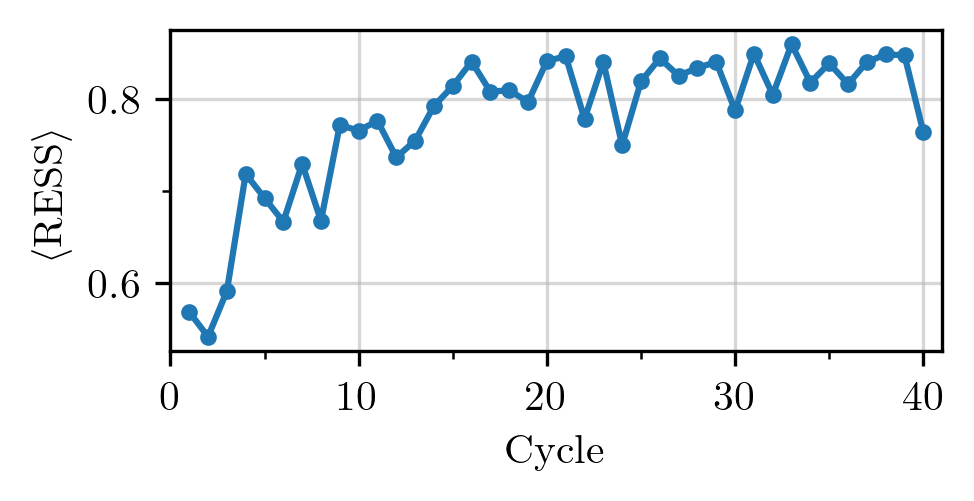

In [12]:
x = np.arange(-2.3, 2.3, 0.005)
X, Y = np.meshgrid(x, x)

committor_values = trainer.aimmd_network.forward_with_sigmoid(torch.tensor([[x[i], x[j]] for j in range(len(x)) for i in range(len(x))], dtype=torch.float32).to(trainer.generator.device)).detach().cpu().numpy().reshape((len(x), len(x)))

fig, ax = plt.subplots(1, 1, figsize=(8.5*TO_CM, 4.5*TO_CM), dpi=300)

ax.plot(np.arange(1, 41), instantaneous_mean_ress[:40], marker='.')

ax.set_xlabel("Cycle")
ax.set_ylabel(r"$\langle$RESS$\rangle$")

ax.xaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.yaxis.set_minor_locator(matplotlib.ticker.AutoMinorLocator(2))
ax.grid(alpha=0.5)

ax.set_xlim((0, 41))

fig.tight_layout()

plt.show()

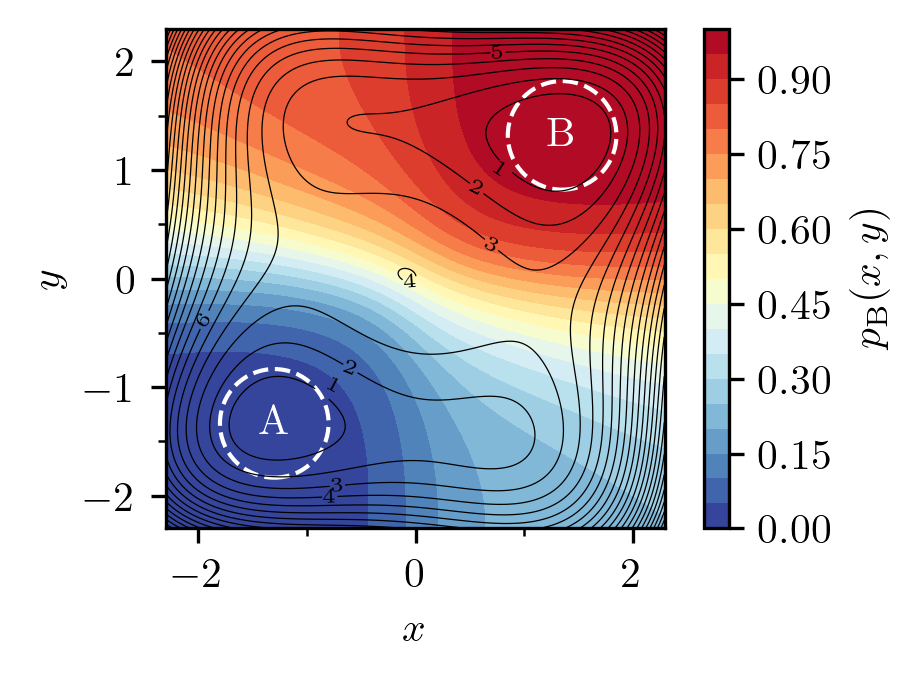

In [ ]:
x = np.arange(-2.3, 2.3, 0.005)
X, Y = np.meshgrid(x, x)

committor_values = trainer.aimmd_network.forward_with_sigmoid(torch.tensor([[x[i], x[j]] for j in range(len(x)) for i in range(len(x))], dtype=torch.float32).to(trainer.generator.device)).detach().cpu().numpy().reshape((len(x), len(x)))

fig, ax = plt.subplots(1, 1, figsize=(8.5*TO_CM, 6*TO_CM), dpi=300)

committor_potential.plot_PES(fig, ax, fill=False)

clabel_texts = list(ax.texts)

contour = ax.contourf(X, Y, committor_values, cmap="RdYlBu_r", levels=20)

cbar = fig.colorbar(contour, ax=ax)
cbar.set_label(r"$p_{\mathrm{B}}(x, y)$")

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

for center, label in zip([committor_potential.A, committor_potential.B], ["A", "B"]):
    circle = matplotlib.patches.Circle(center, radius=0.5, fill=False, linestyle='--', edgecolor='white')
    ax.add_patch(circle)
    ax.text(center[0], center[1], label, color='white', ha='center', va='center')

circle_radius = 0.5
margin = 0.15 
for txt in clabel_texts:
    pos = np.array(txt.get_position())
    for center in [committor_potential.A, committor_potential.B]:
        diff = pos - center
        dist = np.linalg.norm(diff)
        if dist < circle_radius + margin:
            direction = diff / dist if dist > 1e-9 else np.array([1.0, 0.0])
            new_pos = center + direction * (circle_radius + margin)
            txt.set_position(new_pos)
            break

fig.tight_layout()

plt.show()


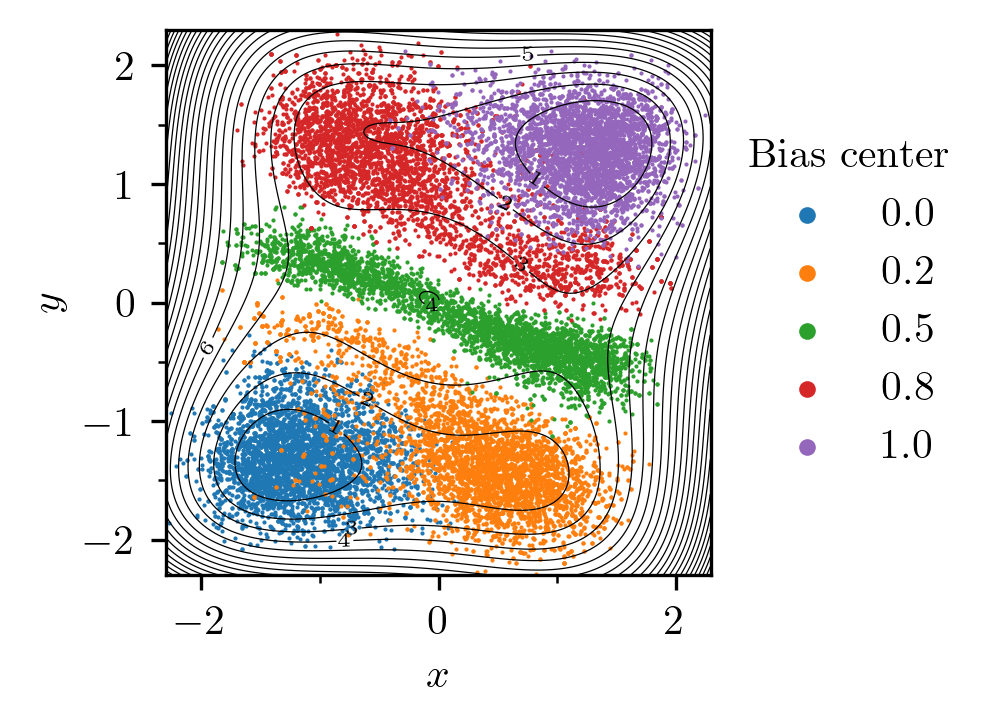

In [22]:
example_bias_centers = [0.0, 0.2, 0.5, 0.8, 1.0]
samples_per_window = 5000

generated_samples = np.empty((len(example_bias_centers), samples_per_window, 3))

for window, example_bias_center in enumerate(example_bias_centers):
    example_input = torch.hstack([trainer.generator.generate_z_samples(samples_per_window).to(generator.device), (torch.ones(samples_per_window, device=trainer.generator.device)*example_bias_center).reshape(-1, 1)]).to(trainer.generator.device)
    samples, log_R_zx = trainer.generator.F_zx(example_input)
    weights = trainer.generator.get_weights(samples, log_R_zx, example_input, normalize=True)
    samples = samples.detach().cpu().numpy()
    weights = weights.detach().cpu().numpy()

    indices_chosen = np.random.choice(len(samples), len(samples), p=weights, replace=True)

    generated_samples[window] = samples[indices_chosen]

fig, ax = plt.subplots(1, 1, figsize=(8.5*TO_CM, 6*TO_CM), dpi=300)

committor_potential.plot_PES(fig, ax, fill=False)

for bias_center, generated_sample in zip(example_bias_centers, generated_samples):
    ax.scatter(generated_sample[:, 0], generated_sample[:, 1], s=1, label=f"{bias_center}", linewidths=0)

ax.set_xlim((-2.3, 2.3))
ax.set_ylim((-2.3, 2.3))

ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

ax.legend(title="Bias center", loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False, markerscale=4)

plt.show()
